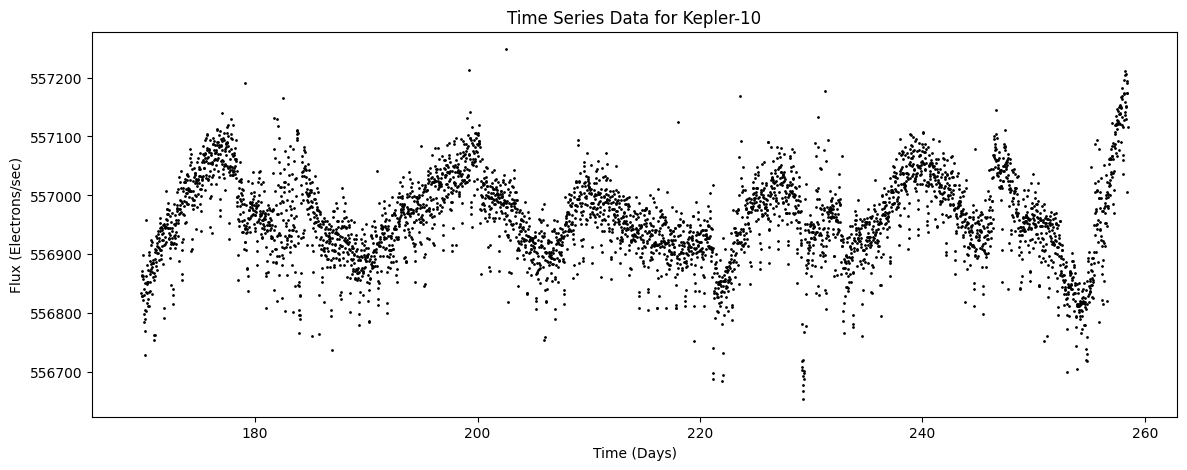

In [44]:
# 1. Install the NASA-supported library


import lightkurve as lk
import matplotlib.pyplot as plt

# 2. Search for a famous confirmed exoplanet (e.g., Kepler-10b, the first rocky planet found by Kepler)
# We search for the host star "Kepler-10"
search_result = lk.search_lightcurve('Kepler-10', author='Kepler', cadence='long')

# 3. Download the data for a specific quarter (e.g., Quarter 3)
lc = search_result[2].download()

# 4. Remove obvious massive outliers and NaN values (Lightkurve has built-in functions for this!)
lc = lc.remove_nans().remove_outliers().fill_gaps()

# 5. Convert it instantly to a Pandas DataFrame for your ARIMA model!
df = lc.to_pandas().reset_index()

# 6. Plot it to see what you got
plt.figure(figsize=(14, 5))
plt.plot(df['time'], df['flux'], color='black', marker='.', linestyle='none', markersize=2)
plt.title('Time Series Data for Kepler-10')
plt.xlabel('Time (Days)')
plt.ylabel('Flux (Electrons/sec)')
plt.show()

In [45]:
print("--- Explicit Missing Values (NaNs) ---")
print(df.isnull().sum())

--- Explicit Missing Values (NaNs) ---
time         0
flux         0
flux_err     0
cadenceno    0
quality      0
dtype: int64


In [46]:
# 1. Calculate the time difference between consecutive rows
df['Time_Step'] = df['time'].diff()

# 2. Find what the "normal" gap is (using median to ignore outliers)
normal_gap = df['Time_Step'].median()

# 3. Find the absolute largest gap in the whole dataset
max_gap = df['Time_Step'].max()

print("--- Hidden Time Gap Analysis ---")
print(f"Normal observation interval: {normal_gap:.4f} days (approx {normal_gap * 24 * 60:.1f} minutes)")
print(f"Largest gap detected:        {max_gap:.4f} days")

# 4. The Logic Check: If the max gap is more than 1.5x the normal gap, sound the alarm!
if max_gap > (normal_gap * 1.5):
    print("\nWARNING: You have a hidden time gap! The telescope turned off.")
    
    # Optional: Find exactly where the gap happened
    gap_location = df[df['Time_Step'] > (normal_gap * 1.5)]
    print("\nHere are the locations of the gaps:")
    print(gap_location[['time', 'Time_Step']])
else:
    print("\nSUCCESS: Your time intervals are perfectly continuous. Safe for ARIMA modeling!")

--- Hidden Time Gap Analysis ---
Normal observation interval: 0.0204 days (approx 29.4 minutes)
Largest gap detected:        0.0204 days

SUCCESS: Your time intervals are perfectly continuous. Safe for ARIMA modeling!


## ARIMA Workflow (Train/Test, Box-Cox, Stationarity, Forecast)
This section:
1. Cleans the flux series and splits train/test with the **test as the tail**.
2. Applies Box-Cox variance stabilization (fit on train only).
3. Finds differencing order using the ADF test.
4. Fits an ARIMA model, runs diagnostics, and forecasts the test horizon.

Total observations: 4342
Train size: 3039
Test size:  1303

Two-harmonic detrending parameters:
train_mean=556956.219233
f=0.064414 cycles/day
beta1=-11.415913, beta2=-31.867446, beta3=7.316575, beta4=4.153299


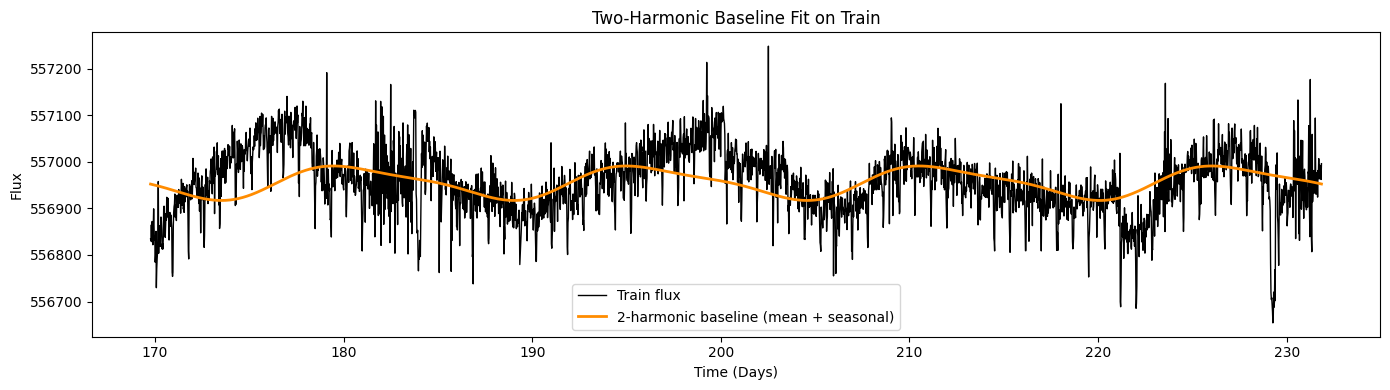


Box-Cox on detrended residuals:
lambda=1.268958
shift=317.595150, scale=315.905879

ADF checks on transformed residual series Xt:
d=0: ADF stat=-4.4019, p-value=0.000295

Selected differencing order (d): 0


In [47]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# -----------------------------
# 1) Clean and split train/test
# -----------------------------
clean_df = (
    df[["time", "flux"]]
    .dropna(subset=["time", "flux"])
    .drop_duplicates(subset=["time"])
    .sort_values("time")
    .reset_index(drop=True)
)

series = clean_df.set_index("time")["flux"].astype(float)

# Tail split: last 30% is test
split_idx = int(len(series) * 0.7)
train = series.iloc[:split_idx].copy()
test = series.iloc[split_idx:].copy()

print(f"Total observations: {len(series)}")
print(f"Train size: {len(train)}")
print(f"Test size:  {len(test)}")

# ----------------------------------------------------------------------
# 2) Harmonic detrending from school model with TWO harmonics:
#    Yt = b1*cos(wt)+b2*sin(wt)+b3*cos(2wt)+b4*sin(2wt)+Xt
# ----------------------------------------------------------------------
mu_train = train.mean()
train_centered = train - mu_train
test_centered = test - mu_train

t_train = train.index.values.astype(float)
t_test = test.index.values.astype(float)
t0 = t_train.min()
t_train_rel = t_train - t0
t_test_rel = t_test - t0

y_train = train_centered.values
y_centered = y_train - np.mean(y_train)

# Estimate dominant frequency f from train using FFT.
dt = np.median(np.diff(t_train_rel))
freqs = np.fft.rfftfreq(len(y_centered), d=dt)
power = np.abs(np.fft.rfft(y_centered))
if len(power) > 2:
    peak_idx = int(np.argmax(power[1:]) + 1)
    f_selected = float(freqs[peak_idx])
else:
    f_selected = 1.0 / max((t_train_rel.max() - t_train_rel.min()), 1e-6)

w = 2.0 * np.pi * f_selected

X_train = np.column_stack([
    np.cos(w * t_train_rel),
    np.sin(w * t_train_rel),
    np.cos(2.0 * w * t_train_rel),
    np.sin(2.0 * w * t_train_rel),
])

# OLS estimate of [beta1, beta2, beta3, beta4]
beta_hat, *_ = np.linalg.lstsq(X_train, y_train, rcond=None)
beta1, beta2, beta3, beta4 = beta_hat

train_harmonic = pd.Series(X_train @ beta_hat, index=train.index, name="train_harmonic")

X_test = np.column_stack([
    np.cos(w * t_test_rel),
    np.sin(w * t_test_rel),
    np.cos(2.0 * w * t_test_rel),
    np.sin(2.0 * w * t_test_rel),
])
test_harmonic = pd.Series(X_test @ beta_hat, index=test.index, name="test_harmonic")

# Xt (residual component) = centered Yt - harmonic baseline
train_resid = pd.Series(train_centered.values - train_harmonic.values, index=train.index, name="train_resid")
test_resid = pd.Series(test_centered.values - test_harmonic.values, index=test.index, name="test_resid")

print("\nTwo-harmonic detrending parameters:")
print(f"train_mean={mu_train:.6f}")
print(f"f={f_selected:.6f} cycles/day")
print(f"beta1={beta1:.6f}, beta2={beta2:.6f}, beta3={beta3:.6f}, beta4={beta4:.6f}")

# Plot baseline on original scale (mean + harmonic)
plt.figure(figsize=(14, 4))
plt.plot(train.index, train.values, label="Train flux", color="black", linewidth=1)
plt.plot(train.index, (mu_train + train_harmonic.values), label="2-harmonic baseline (mean + seasonal)", color="darkorange", linewidth=2)
plt.title("Two-Harmonic Baseline Fit on Train")
plt.xlabel("Time (Days)")
plt.ylabel("Flux")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# 3) Box-Cox AFTER detrending: apply to residual component Xt only
# -----------------------------------------------------------------
shift_resid = 0.0
if train_resid.min() <= 0:
    shift_resid = 1.0 - train_resid.min()

train_resid_pos = train_resid + shift_resid
test_resid_pos = test_resid + shift_resid

scale_resid = np.median(train_resid_pos)
if not np.isfinite(scale_resid) or scale_resid <= 0:
    scale_resid = 1.0

train_resid_scaled = train_resid_pos / scale_resid
test_resid_scaled = test_resid_pos / scale_resid

train_boxcox_vals, boxcox_lambda = boxcox(train_resid_scaled.values)

# If lambda is numerically extreme, use identity transform (lambda=1).
if (not np.isfinite(boxcox_lambda)) or (abs(boxcox_lambda) > 10):
    boxcox_lambda = 1.0

if boxcox_lambda == 1.0:
    train_boxcox = train_resid_scaled.copy()
    test_boxcox = test_resid_scaled.copy()
else:
    train_boxcox = pd.Series(train_boxcox_vals, index=train_resid.index, name="train_boxcox")
    test_boxcox = pd.Series(boxcox(test_resid_scaled.values, lmbda=boxcox_lambda), index=test_resid.index, name="test_boxcox")

if (not np.isfinite(train_boxcox).all()) or (not np.isfinite(test_boxcox).all()):
    boxcox_lambda = 1.0
    train_boxcox = train_resid_scaled.copy()
    test_boxcox = test_resid_scaled.copy()

print("\nBox-Cox on detrended residuals:")
print(f"lambda={boxcox_lambda:.6f}")
print(f"shift={shift_resid:.6f}, scale={scale_resid:.6f}")

# -----------------------------------------------------
# 4) Determine differencing order with ADF on Box-Cox Xt
# -----------------------------------------------------
def adf_report(x, label):
    result = adfuller(x.dropna(), autolag="AIC")
    print(f"{label}: ADF stat={result[0]:.4f}, p-value={result[1]:.6f}")
    return result[1]

print("\nADF checks on transformed residual series Xt:")
d = 0
p_value = adf_report(train_boxcox, "d=0")

while p_value > 0.05 and d < 2:
    d += 1
    p_value = adf_report(train_boxcox.diff(d).dropna(), f"d={d}")

print(f"\nSelected differencing order (d): {d}")
if p_value > 0.05:
    print("Warning: series may still be non-stationary at d<=2; proceeding with best found d.")

# Keep for next cell
train_arima_input = train_boxcox
test_boxcox_target = test_boxcox
d_selected = d
lambda_selected = boxcox_lambda
shift_selected = shift_resid
scale_selected = scale_resid
harmonic_train = train_harmonic
harmonic_test = test_harmonic
train_mean_selected = mu_train
frequency_selected = f_selected
beta1_selected = beta1
beta2_selected = beta2
beta3_selected = beta3
beta4_selected = beta4

Best ARIMA order by AIC (Xt model): (3, 0, 1)
Best AIC: -3389.805

                               SARIMAX Results                                
Dep. Variable:           train_boxcox   No. Observations:                 3039
Model:                 ARIMA(3, 0, 1)   Log Likelihood                1700.902
Date:                Tue, 24 Mar 2026   AIC                          -3389.805
Time:                        21:31:25   BIC                          -3353.689
Sample:                             0   HQIC                         -3376.822
                               - 3039                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0019      0.047     -0.041      0.967      -0.095       0.091
ar.L1          1.2780      0.015     82.948      0.000       1.2

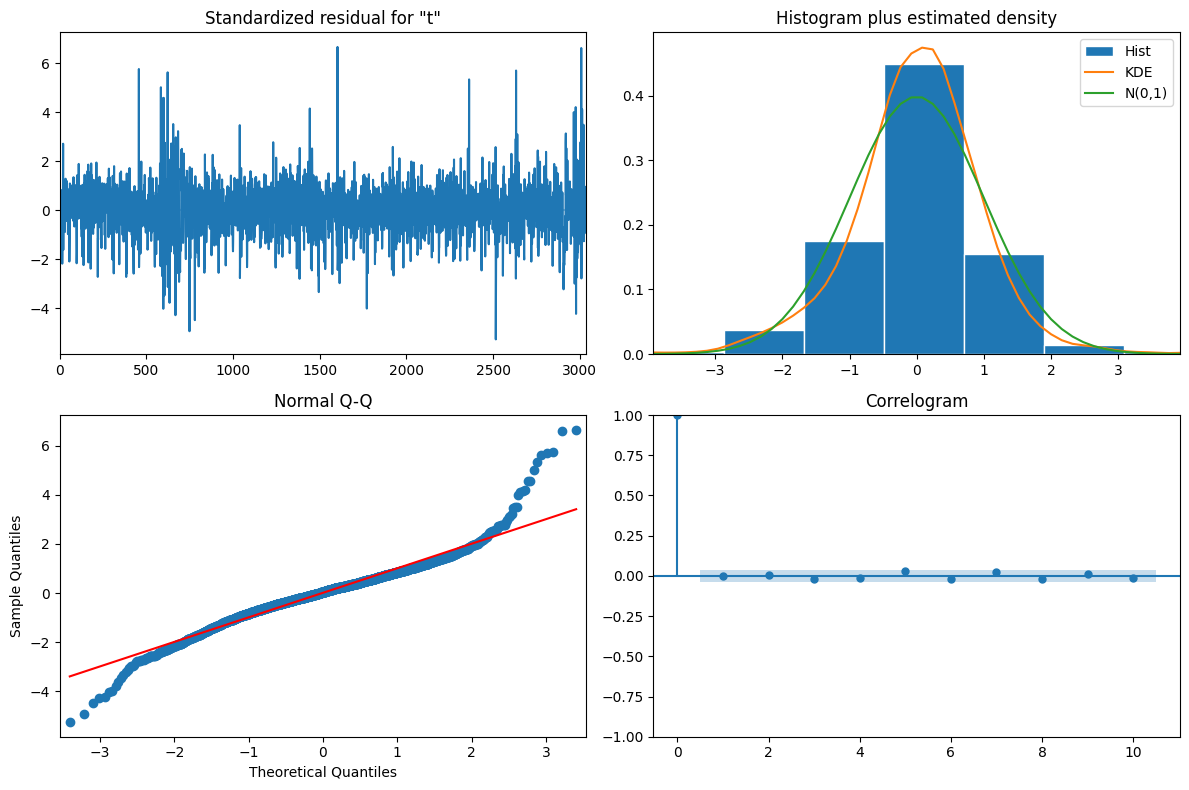

Forecast accuracy on test set (harmonic + ARIMA):
MAE : 61.509655
RMSE: 77.510207


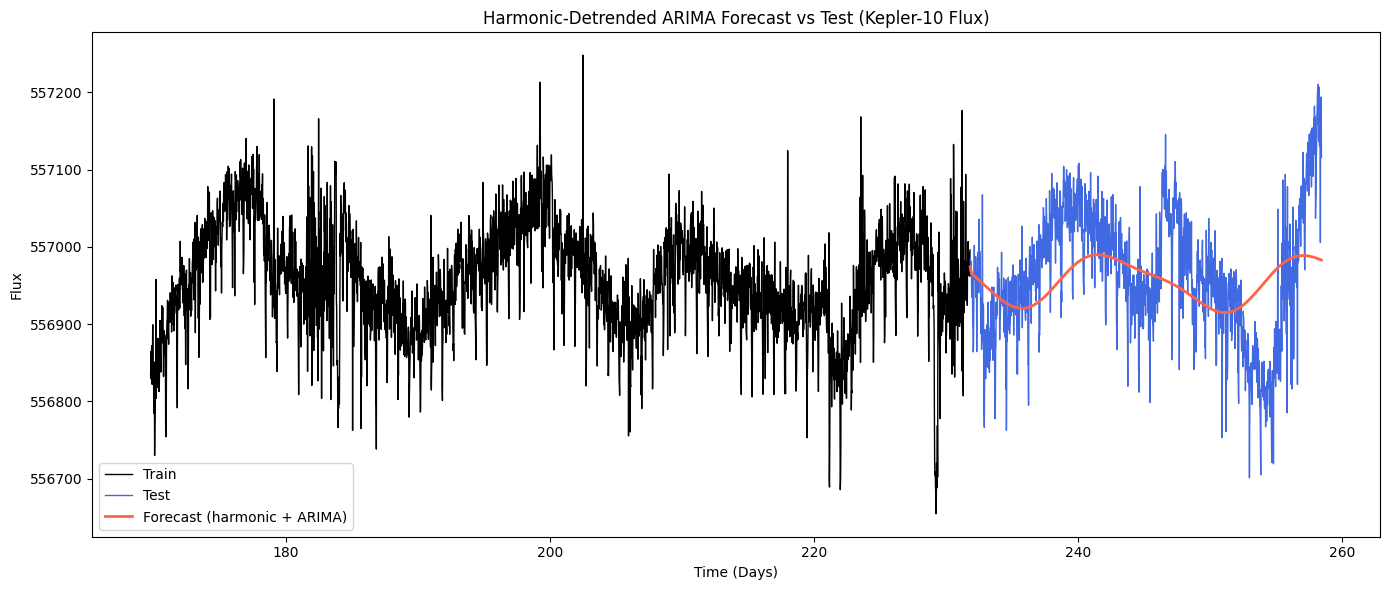

In [48]:
# ------------------------------------------
# 5) Fit ARIMA model on transformed Xt noise
# ------------------------------------------
best_aic = np.inf
best_order = None
best_model = None

for p in range(0, 4):
    for q in range(0, 4):
        order = (p, d_selected, q)
        try:
            model = ARIMA(train_arima_input, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

if best_model is None:
    raise RuntimeError("Could not fit any ARIMA model in the searched grid.")

print(f"Best ARIMA order by AIC (Xt model): {best_order}")
print(f"Best AIC: {best_aic:.3f}\n")
print(best_model.summary())

# ----------------------
# 6) Model diagnostics
# ----------------------
best_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) Forecast Xt, invert transform, then add harmonic baseline
# ------------------------------------------------------------
steps = len(test)
forecast_boxcox = best_model.forecast(steps=steps)
forecast_boxcox = pd.Series(forecast_boxcox.values, index=test.index, name="forecast_boxcox")

if lambda_selected == 1.0:
    forecast_resid_scaled = forecast_boxcox
else:
    forecast_resid_scaled = inv_boxcox(forecast_boxcox, lambda_selected)

forecast_resid = (forecast_resid_scaled * scale_selected) - shift_selected
forecast_resid = pd.Series(forecast_resid, index=test.index, name="forecast_resid")

# Final forecast on original scale: train mean + harmonic component + predicted Xt
forecast_flux = train_mean_selected + harmonic_test + forecast_resid
forecast_flux = pd.Series(forecast_flux.values, index=test.index, name="forecast_flux")

mae = mean_absolute_error(test, forecast_flux)
rmse = np.sqrt(mean_squared_error(test, forecast_flux))

print("Forecast accuracy on test set (harmonic + ARIMA):")
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

# Plot train, test, and forecast
plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label="Train", color="black", linewidth=1)
plt.plot(test.index, test.values, label="Test", color="royalblue", linewidth=1)
plt.plot(forecast_flux.index, forecast_flux.values, label="Forecast (harmonic + ARIMA)", color="tomato", linewidth=2)
plt.title("Harmonic-Detrended ARIMA Forecast vs Test (Kepler-10 Flux)")
plt.xlabel("Time (Days)")
plt.ylabel("Flux")
plt.legend()
plt.tight_layout()
plt.show()